FOR NUMERICAL DATA


Missing Indicator imputer

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('titanic_train.csv', usecols = ['Age', 'Fare', 'Survived'])

In [3]:
df.head()


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean()*100


Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:
x = df.drop(columns = ['Survived'])
y = df['Survived']

In [6]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2, random_state = 2)

In [7]:
x_train['Age_imputed'] = x_train['Age']
x_test['Age_imputed'] = x_test['Age']

In [27]:
x_train.tail()


,Age,Fare,Age_imputed
534,30.0,8.6625,30.0
584,NaN,8.7125,NaN
493,71.0,49.5042,71.0
527,NaN,221.7792,NaN
168,NaN,25.9250,NaN


In [14]:
x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values


array([29.  , 19.  , 20.  , 15.  , 30.  , 19.  ,  9.  , 43.  , 35.  ,
       33.  , 46.  , 29.  , 52.  , 30.  , 19.  , 25.  ,  2.  , 33.  ,
       18.  , 23.  ,  4.  , 71.  , 32.  , 54.  , 28.  , 26.  , 25.  ,
       25.  , 48.  , 13.  , 22.  , 25.  , 34.  , 22.  , 58.  , 47.  ,
       16.  , 32.5 , 24.  , 29.  , 70.5 ,  1.  , 21.  , 41.  , 38.  ,
       34.  , 31.  , 70.  , 21.  , 50.  , 33.  , 37.  , 49.  , 64.  ,
        9.  , 27.  , 30.  , 39.  , 21.  , 11.  , 27.  , 56.  , 45.  ,
       58.  , 29.  , 21.  , 25.  , 15.  , 36.  ,  0.42, 50.  , 28.  ,
       21.  , 60.  , 16.  , 36.  , 30.  , 32.  , 26.  ,  1.  ,  2.  ,
       25.  , 19.  , 35.  , 27.  ,  9.  , 24.  , 24.  , 35.  , 22.  ,
       60.  , 56.  , 53.  ,  8.  , 23.  , 26.  , 22.  , 16.  ,  9.  ,
       38.  , 38.  , 40.5 , 31.  , 36.  , 45.5 , 29.  , 30.  , 39.  ,
       23.  , 29.  , 40.  , 22.  , 10.  , 14.  , 17.  , 31.  , 26.  ,
       25.  , 59.  , 33.  , 42.  , 47.  ,  8.  , 40.  , 33.  , 30.  ,
       20.  , 52.  ,

In [26]:
x_train['Age'].dropna().sample()


784    25.0
Name: Age, dtype: float64

In [31]:
#nan values in age imputed have been replaced by random values froma ge
x_train['Age_imputed'][x_train['Age_imputed'].isnull()]  = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values

x_test['Age_imputed'][x_test['Age_imputed'].isnull()] = x_test['Age'].dropna().sample(x_test['Age'].isnull().sum())

ValueError: cannot set using a list-like indexer with a different length than the value

In [32]:
# train
null_mask_train = x_train['Age_imputed'].isnull()

#Creates a boolean Series — True where Age_imputed is NaN, False elsewhere. Stored so we can reuse it without repeating the condition.
x_train.loc[null_mask_train, 'Age_imputed'] = (
    x_train['Age'].dropna()
    .sample(null_mask_train.sum(), replace=True)
    .values
)

# test
null_mask_test = x_test['Age_imputed'].isnull()
x_test.loc[null_mask_test, 'Age_imputed'] = (
    x_test['Age'].dropna()
    .sample(null_mask_test.sum(), replace=True)
    .values


#.loc[row_condition, column] — targets only the NaN rows in Age_imputed for assignment. Whatever is on the right side gets written into exactly those cells.


    #.sum() on a boolean mask counts the Trues — i.e. how many NaNs need filling. .sample(n) picks that many random values from the pool. replace=True allows the same value to be picked more than once (necessary when nulls > available values).
)

In [37]:
x_train.sample(15)


,Age,Fare,Age_imputed
207,26.0,18.7875,26.0
111,14.5,14.4542,14.5
319,40.0,134.5000,40.0
395,22.0,7.7958,22.0
742,21.0,262.3750,21.0
853,16.0,39.4000,16.0
530,2.0,26.0000,2.0
525,40.5,7.7500,40.5
175,18.0,7.8542,18.0
442,25.0,7.7750,25.0


/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_6386/244408704.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'], label = 'Original' ,hist = False)
/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_6386/244408704.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750

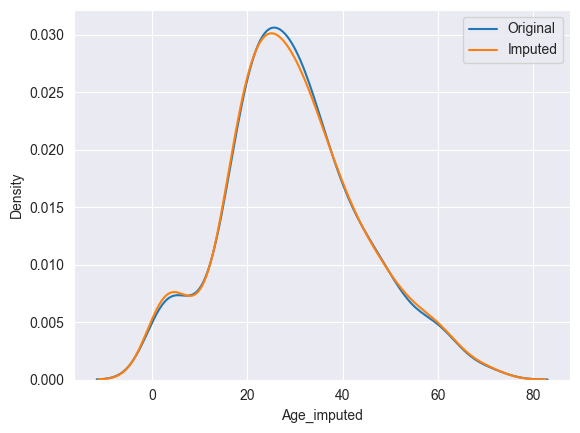

In [39]:
sns.distplot(x_train['Age'], label = 'Original' ,hist = False)
sns.distplot(x_train['Age_imputed'], label = 'Imputed', hist = False )

plt.legend()
plt.show()

In [40]:
print('original variable variance :', x_train['Age'].var())
print('imputed variable variance :', x_train['Age_imputed'].var())

original variable variance : 204.34951339046142
imputed variable variance : 210.0912338514752


In [41]:
x_train[['Fare', 'Age', 'Age_imputed']].cov()


,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,62.851663
Age,71.512440,204.349513,204.349513
Age_imputed,62.851663,204.349513,210.091234


<Axes: >

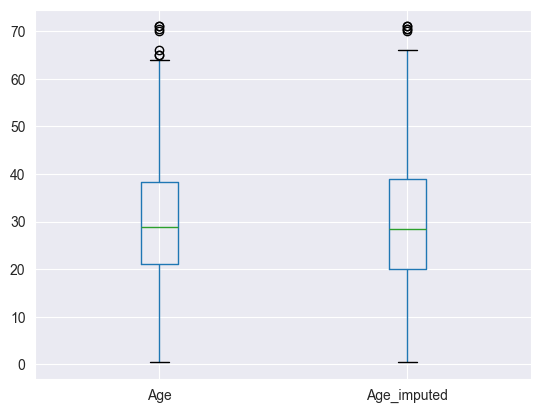

In [42]:
#outliers inspection
x_train[['Age' , 'Age_imputed']].boxplot()

In [44]:
observation = x_train.loc[0]   # row at index 0
fare = observation['Fare']
rs = int(fare) if pd.notna(fare) else 42   # 42 or any default seed

sampled_value = x_train['Age'].dropna().sample(1, random_state = rs)

FOR CATEGORICAL DATA / MISSING DATA IMPUTATION

In [45]:
data = pd.read_csv('housing.csv' , usecols = ['GarageQual', 'FireplaceQu','SalePrice'])

In [46]:
data.head()


,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [48]:
data.isnull().mean()*100


FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [49]:
x = data.drop(columns = ['SalePrice'])
y = data['SalePrice']

In [50]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 2 )

In [52]:
x_train['GarageQual_imputed'] = x_train['GarageQual']
x_test['GarageQual_imputed'] = x_test['GarageQual']



x_train['FireplaceQu_imputed'] = x_train['FireplaceQu']
x_test['FireplaceQu_imputed'] = x_test['FireplaceQu']

In [54]:
x_train.sample(10)


,FireplaceQu,GarageQual,GarageQual_imputed,FireplaceQu_imputed
1162,Po,TA,TA,Po
1183,Gd,TA,TA,Gd
427,NaN,TA,TA,NaN
1001,NaN,Fa,Fa,NaN
321,Gd,TA,TA,Gd
1060,NaN,TA,TA,NaN
258,TA,TA,TA,TA
1385,NaN,TA,TA,NaN
851,TA,TA,TA,TA
799,TA,TA,TA,TA


In [86]:
null_mask_train = x_train['GarageQual_imputed'].isnull()
x_train.loc[null_mask_train, 'GarageQual_imputed'] = x_train['GarageQual'].dropna().sample(null_mask_train.sum(), replace=True).values

null_mask_train2 = x_train['FireplaceQu_imputed'].isnull()
x_train.loc[null_mask_train2, 'FireplaceQu_imputed'] = x_train['FireplaceQu'].dropna().sample(null_mask_train2.sum(), replace=True).values

In [91]:
temp = pd.concat(
    [
        x_train['GarageQual'].value_counts()/len(x_train['GarageQual'].dropna()) , x_train['GarageQual_imputed'].value_counts() / len(x_train['GarageQual_imputed'])
    ] ,axis = 1)
temp.columns = ['original ', 'imputed ']


In [92]:
temp

,original,imputed
TA,0.951043,0.949486
Fa,0.037171,0.036815
Gd,0.009973,0.011986
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [97]:
temp = pd.concat([
    x_train['FireplaceQu'].value_counts()/len(x_train['FireplaceQu'].dropna()) , x_train['FireplaceQu_imputed'].value_counts()/len(x_train['FireplaceQu'].dropna())
] , axis = 1)
temp.columns = ['original' , 'imputed']

temp

,original,imputed
Gd,0.494272,0.949264
TA,0.412439,0.780687
Fa,0.040917,0.090016
Po,0.027823,0.054010
Ex,0.024550,0.037643


In [101]:
data['SalePrice']

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

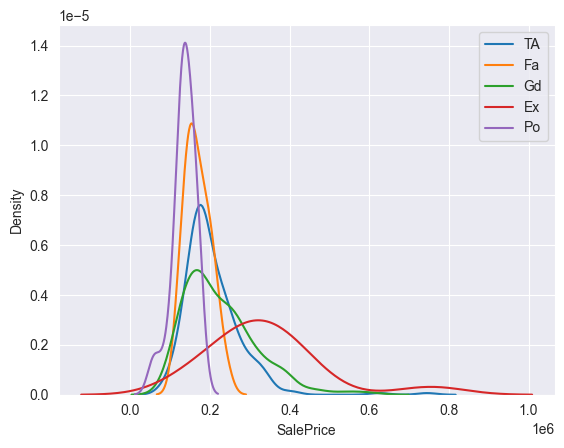

In [117]:
plot_data = x_train.copy()
plot_data['SalePrice'] = y_train.values


for category in plot_data['FireplaceQu'].dropna().unique():
    sns.kdeplot(x=plot_data[plot_data['FireplaceQu'] == category]['SalePrice'], label=category)

plt.legend()
plt.show()

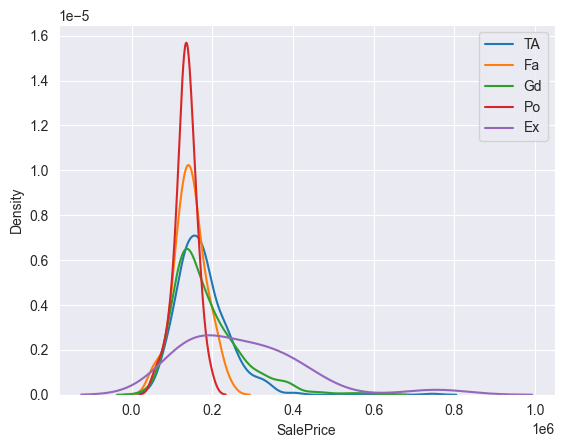

In [118]:
plot_data = x_train.copy()
plot_data['SalePrice'] = y_train.values

for category in plot_data['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(x=plot_data[plot_data['FireplaceQu_imputed'] == category]['SalePrice'], label=category)

plt.legend()
plt.show()